# Executive Credit Analysis

A Credit Risk Director-style walkthrough of the portfolio: where risk is concentrated, what is driving it, how it has evolved, and what stress testing reveals. Requires `make data && make features && make train` to have been run first.

In [1]:
import sys, json
sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

scored = pd.read_parquet('../data/processed/scored_portfolio.parquet')
features = pd.read_parquet('../data/processed/credit_features.parquet')
panel = pd.read_parquet('../data/raw/monthly_performance.parquet')
customers = pd.read_parquet('../data/raw/customer_portfolio.parquet')
print(scored.shape, features.shape, panel.shape)

(100000, 11) (100000, 38) (1542441, 7)


## 1. Where Is Risk Concentrated?

In [2]:
band_stats = scored.groupby('risk_band').agg(
    n_customers=('customer_id', 'count'),
    total_exposure=('ead', 'sum'),
    total_expected_loss=('expected_loss', 'sum'),
    avg_pd=('pd', 'mean'),
).reindex(list('ABCDE'))
band_stats

,n_customers,total_exposure,total_expected_loss,avg_pd
risk_band,,,,
A,26857,1.999321e+08,7.686088e+05,0.005755
B,31500,2.691682e+08,4.064769e+06,0.022978
C,25232,2.303019e+08,1.247324e+07,0.083200
D,14515,1.350089e+08,2.141486e+07,0.243204
E,1896,1.848433e+07,6.045381e+06,0.503380


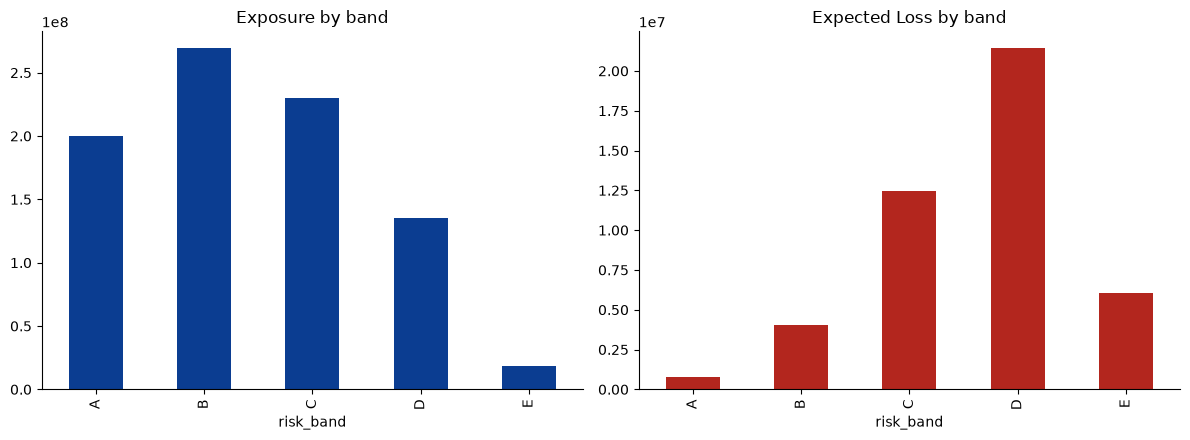

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
band_stats['total_exposure'].plot(kind='bar', ax=axes[0], color='#0B3D91', title='Exposure by band')
band_stats['total_expected_loss'].plot(kind='bar', ax=axes[1], color='#B3261E', title='Expected Loss by band')
plt.tight_layout()
plt.show()

**Interpretation for the Credit Risk Director.** Exposure is concentrated in the lower-risk bands (A/B) as expected for a healthy book, but Expected Loss is disproportionately concentrated in bands D and E - a small share of accounts drives a large share of expected losses, which is exactly where collections/monitoring attention should focus first.

## 2. Which Segments Deteriorated the Most?

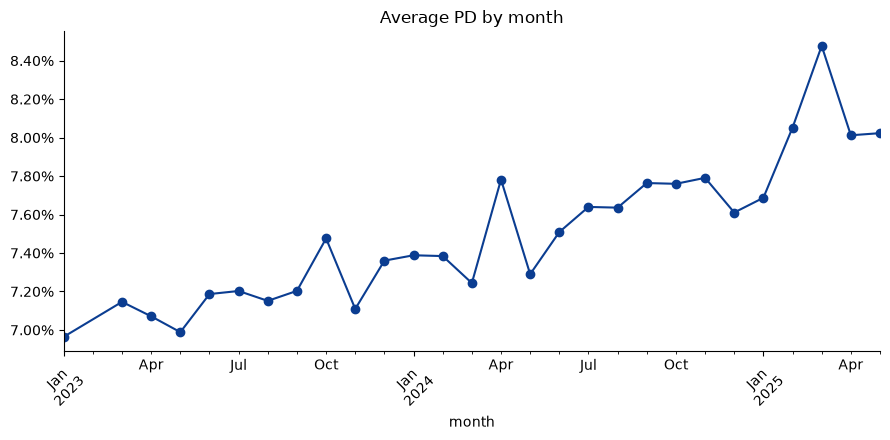

First 3 months avg PD: 0.07060427053292581
Last 3 months avg PD: 0.08170668613474803


In [4]:
scored['month'] = pd.to_datetime(scored['observation_date']).dt.to_period('M')
monthly_pd = scored.groupby('month')['pd'].mean()
fig, ax = plt.subplots()
monthly_pd.plot(ax=ax, marker='o', color='#0B3D91', title='Average PD by month')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print('First 3 months avg PD:', monthly_pd.head(3).mean())
print('Last 3 months avg PD:', monthly_pd.tail(3).mean())

**Interpretation.** Average PD is mildly higher in the most recent months than at the start of the observation window, consistent with the synthetic portfolio's designed deterioration drift (`docs/PORTFOLIO_STORY.md`). This kind of slow drift is exactly what population-stability monitoring (`detect_drift`) is meant to catch before it becomes a material issue.

## 3. Which Variables Anticipate Default? (SHAP)

In [5]:
from src.models.explainability import build_default_explainer
from src.models.train import split_xy

explainer, feat_df, metadata = build_default_explainer()
categories = metadata['categories']
x_test, _ = split_xy(feat_df, 'test', categories)
sample = x_test.sample(min(500, len(x_test)), random_state=1)
importance = explainer.global_importance(sample).head(10)
importance

Background dataset has 300 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=300 when initializing the masker.


,feature,mean_abs_shap
0,behavioral_score,0.311950
1,debt_to_income,0.308290
2,late_payments_12m,0.290704
3,utilization_gap_to_limit,0.289935
4,financial_stability_index,0.231844
5,payment_stress_index,0.161089
6,balance_trend,0.128951
7,behavioral_deterioration_index,0.095428
8,payment_history_Poor,0.090229
9,delinquency_trend,0.076445


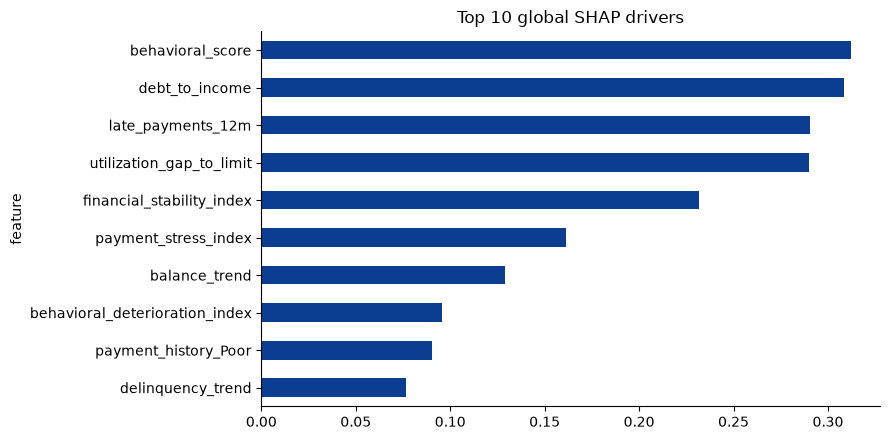

In [6]:
fig, ax = plt.subplots()
importance.set_index('feature')['mean_abs_shap'].sort_values().plot(
    kind='barh', ax=ax, color='#0B3D91', title='Top 10 global SHAP drivers'
)
plt.tight_layout()
plt.show()

**Interpretation.** The model's globally most important drivers align with credit risk domain intuition - debt service burden, delinquency history, and composite behavioral indicators dominate, with no protected/sensitive characteristic anywhere in the list (there is none in the dataset - see `RESPONSIBLE_AI.md`).

## 4. How Has the Portfolio Evolved?

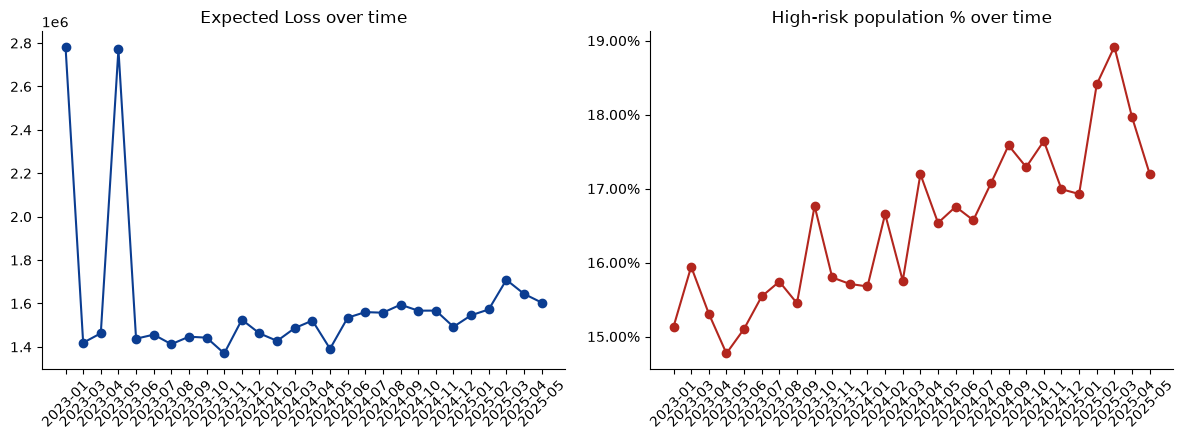

In [7]:
from src.analytics.portfolio import monthly_kpi_trend

trend = monthly_kpi_trend(scored, features)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(trend['month'], trend['expected_loss'], marker='o', color='#0B3D91')
axes[0].set_title('Expected Loss over time')
axes[0].tick_params(axis='x', rotation=45)
axes[1].plot(trend['month'], trend['high_risk_population_pct'], marker='o', color='#B3261E')
axes[1].set_title('High-risk population % over time')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Interpretation.** Both Expected Loss and the high-risk population share should be read together with account volume: a rising EL trend during a period of portfolio growth is a very different signal than the same trend on a flat book.

## 5. How Did Risk Change Across Vintages?

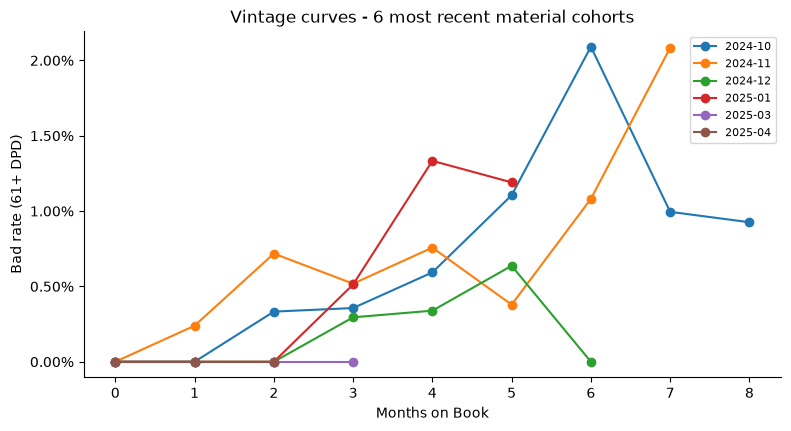

In [8]:
from src.analytics.vintage import build_vintage_curves, filter_material_cohorts

curves = build_vintage_curves(panel, customers)
curves = filter_material_cohorts(curves, min_accounts=30)
recent = sorted(curves['origination_cohort'].unique())[-6:]
fig, ax = plt.subplots()
for cohort in recent:
    sub = curves[curves['origination_cohort'] == cohort]
    ax.plot(sub['mob'], sub['bad_rate'], marker='o', label=cohort)
ax.set_xlabel('Months on Book')
ax.set_ylabel('Bad rate (61+ DPD)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('Vintage curves - 6 most recent material cohorts')
ax.legend(fontsize=8)
plt.show()

**Interpretation.** Comparing cohorts at the same MOB checkpoint isolates genuine credit-quality differences between origination periods from simple portfolio-aging effects - a cohort whose curve sits persistently above its peers at the same MOB warrants underwriting-policy review for that origination period.

## 6. What Impacts Appeared in Stress Testing?

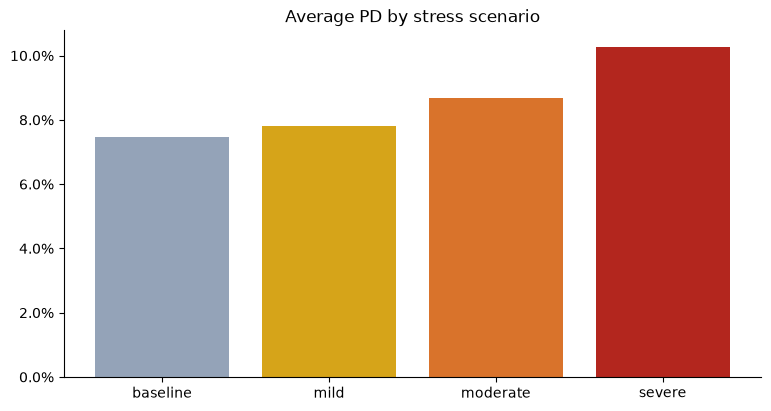

baseline avg PD=7.46% EL delta=-56,808
mild avg PD=7.82% EL delta=+2,063,699
moderate avg PD=8.69% EL delta=+8,810,646
severe avg PD=10.27% EL delta=+20,499,522


In [9]:
with open('../reports/stress_test_report.json') as f:
    stress = json.load(f)

scenarios = ['baseline', 'mild', 'moderate', 'severe']
avg_pd = [stress[s]['stressed']['average_pd'] for s in scenarios]
fig, ax = plt.subplots()
ax.bar(scenarios, avg_pd, color=['#94A3B8', '#D6A419', '#D9732B', '#B3261E'])
ax.set_title('Average PD by stress scenario')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.show()
for s in scenarios:
    print(s, f"avg PD={stress[s]['stressed']['average_pd']:.2%}", f"EL delta={stress[s]['expected_loss_delta']:+,.0f}")

**Interpretation for the Credit Risk Director.** Under the Severe scenario (income -20%, expenses +15%, utilization +10pp), portfolio average PD rises from baseline to a materially higher level and Expected Loss increases by tens of millions in exposure-equivalent terms. This is a hypothetical simulation, not a forecast (see `RESPONSIBLE_AI.md`), but it quantifies the book's sensitivity to a plausible macro shock and supports a capital/provisioning discussion.

## Summary for the Credit Risk Director

- Risk is concentrated in a small, well-identified share of accounts (bands D/E).
- The portfolio shows a mild, monitored upward drift in average PD.
- SHAP confirms the model's decisions track domain-standard credit risk drivers.
- Vintage analysis localizes any deterioration to specific origination cohorts rather than a uniform book-wide effect.
- Severe stress testing shows a material but bounded increase in expected loss, useful input for a provisioning/capital conversation - not a decision by itself.